In [1]:
import numpy as np
import pandas as pd

import dask.dataframe as dd
import dask.array as da
import dask.bag as db

In [2]:
index = pd.date_range("2021-09-01", periods=2400, freq="1h")
df = pd.DataFrame({"a": np.arange(2400), "b": list("abcaddbe" * 300)}, index=index)
ddf = dd.from_pandas(df, npartitions=10)
ddf

,a,b
npartitions=10,,
2021-09-01 00:00:00,int64,string
2021-09-11 00:00:00,...,...
...,...,...
2021-11-30 00:00:00,...,...
2021-12-09 23:00:00,...,...


In [3]:
# check the index values covered by each partition
ddf.divisions

(Timestamp('2021-09-01 00:00:00'),
 Timestamp('2021-09-11 00:00:00'),
 Timestamp('2021-09-21 00:00:00'),
 Timestamp('2021-10-01 00:00:00'),
 Timestamp('2021-10-11 00:00:00'),
 Timestamp('2021-10-21 00:00:00'),
 Timestamp('2021-10-31 00:00:00'),
 Timestamp('2021-11-10 00:00:00'),
 Timestamp('2021-11-20 00:00:00'),
 Timestamp('2021-11-30 00:00:00'),
 Timestamp('2021-12-09 23:00:00'))

In [4]:
# access a particular partition
ddf.partitions[1]

,a,b
npartitions=1,,
2021-09-11,int64,string
2021-09-21,...,...


In [5]:
ddf.b

Dask Series Structure:
npartitions=10
2021-09-01 00:00:00    string
2021-09-11 00:00:00       ...
                        ...  
2021-11-30 00:00:00       ...
2021-12-09 23:00:00       ...
Dask Name: getitem, 2 expressions
Expr=df['b']

In [6]:
ddf["2021-10-01": "2021-10-09 5:00"]

,a,b
npartitions=1,,
2021-10-01 00:00:00.000000,int64,string
2021-10-09 05:00:59.999999,...,...


In [7]:
ddf["2021-10-01": "2021-10-09 5:00"].compute()

,a,b
2021-10-01 00:00:00,720,a
2021-10-01 01:00:00,721,b
2021-10-01 02:00:00,722,c
2021-10-01 03:00:00,723,a
2021-10-01 04:00:00,724,d
...,...,...
2021-10-09 01:00:00,913,b
2021-10-09 02:00:00,914,c
2021-10-09 03:00:00,915,a
2021-10-09 04:00:00,916,d


In [8]:
ddf.a.mean()

<dask_expr.expr.Scalar: expr=df['a'].mean(), dtype=float64>

In [9]:
ddf.a.mean().compute()

np.float64(1199.5)

In [10]:
ddf.b.unique()

Dask Series Structure:
npartitions=10
    string
       ...
     ...  
       ...
       ...
Dask Name: unique, 3 expressions
Expr=Unique(frame=df['b'])

In [11]:
ddf.b.unique().compute()

0    e
0    c
1    d
0    a
0    b
Name: b, dtype: string

In [12]:
result = ddf["2021-10-01": "2021-10-09 5:00"].a.cumsum() - 100
result

Dask Series Structure:
npartitions=1
2021-10-01 00:00:00.000000    int64
2021-10-09 05:00:59.999999      ...
Dask Name: sub, 5 expressions
Expr=CumSum(frame=(LocSlice(frame=df, iindexer=slice(Timestamp('2021-10-01 00:00:00'), Timestamp('2021-10-09 05:00:59.999999'), None)))['a'], skipna=True) - 100

In [13]:
result.compute()

2021-10-01 00:00:00       620
2021-10-01 01:00:00      1341
2021-10-01 02:00:00      2063
2021-10-01 03:00:00      2786
2021-10-01 04:00:00      3510
                        ...  
2021-10-09 01:00:00    158301
2021-10-09 02:00:00    159215
2021-10-09 03:00:00    160130
2021-10-09 04:00:00    161046
2021-10-09 05:00:00    161963
Freq: h, Name: a, Length: 198, dtype: int64

In [14]:
result.dask

{('sub-3f2d269874d76b449eb16d85410f946d',
  0): <Task ('sub-3f2d269874d76b449eb16d85410f946d', 0) sub(...)>,
 ('cumulativefinalize-1c1fe307ad2c5875eec02928a8fc5be7',
  0): ('cumsum-0dc2b332388b957425a12fa2260a52e6', 0),
 ('operation-354f3404c439f0e0e8ed6447f268026e',
  0): <Task ('operation-354f3404c439f0e0e8ed6447f268026e', 0) operation(...)>,
 ('cumsum-0dc2b332388b957425a12fa2260a52e6',
  0): <Task ('cumsum-0dc2b332388b957425a12fa2260a52e6', 0) cumsum(...)>,
 ('getitem-2da86d4aa9fd0e6e9e5477679393f48c',
  0): <Task ('getitem-2da86d4aa9fd0e6e9e5477679393f48c', 0) getitem(...)>,
 ('loc-df50e5969dd8e03d84c90088c7f711d3',
  0): <Task ('loc-df50e5969dd8e03d84c90088c7f711d3', 0) loc(...)>,
 ('partitions-7b687317b84902ac4d57c9e39c10b982',
  0): Alias(('partitions-7b687317b84902ac4d57c9e39c10b982', 0)->('frompandas-e2d8f48cd3cc3d8e3c10f41c983692fb', 3)),
 ('frompandas-e2d8f48cd3cc3d8e3c10f41c983692fb',
  0): DataNode(                       a  b
 2021-09-01 00:00:00    0  a
 2021-09-01 01:00:

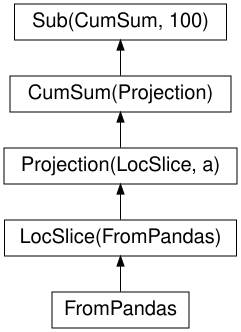

In [15]:
result.visualize()

In [16]:
import dask

@dask.delayed
def inc(x):
   return x + 1

@dask.delayed
def add(x, y):
   return x + y

a = inc(1)       # no work has happened yet
b = inc(2)       # no work has happened yet
c = add(a, b)    # no work has happened yet

c = c.compute()  # This triggers all of the above computations

In [17]:
from dask.distributed import Client
client = Client()
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:8787/status,
Dashboard: http://127.0.0.1:8787/status,Workers: 8
Total threads: 32,Total memory: 62.43 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:38229,Workers: 0
Dashboard: http://127.0.0.1:8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:38997,Total threads: 4
Dashboard: http://127.0.0.1:39849/status,Memory: 7.80 GiB
Nanny: tcp://127.0.0.1:45079,


In [18]:
client.dashboard_link

'http://127.0.0.1:8787/status'